In [4]:
import pandas as pd
import glob
import os


path = '/content/drive/MyDrive/ToN-IoT-CodeAndCSV'
all_files = glob.glob(os.path.join(path, "Network_dataset_*.csv"))

final_list = []

for f in all_files:
    print(f"Processing {f}...")

    temp_df = pd.read_csv(f, low_memory=False)


    filtered = temp_df[(temp_df["type"].str.lower().str.contains("ransom", na=False)) |
                       (temp_df["type"].str.lower() == "normal")]

    final_list.append(filtered)

    del temp_df


df_combined = pd.concat(final_list, ignore_index=True)
print("DONE! Combined shape:", df_combined.shape)

Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_19.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_20.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_21.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_22.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_23.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_1.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_2.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_3.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_4.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_5.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_6.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Network_dataset_7.csv...
Processing /content/drive/MyDrive/ToN-IoT-CodeAndCSV/Networ

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd


keep_features = ["src_bytes","dst_bytes","src_pkts","dst_pkts","duration","conn_state","proto","service","src_port","dst_port","dns_qtype","dns_rcode","dns_rejected"]
X = df_combined[keep_features].copy()
y = df_combined["label"].astype(int)


X["src_bytes"] = pd.to_numeric(X["src_bytes"], errors="coerce").fillna(0)
X["dst_bytes"] = pd.to_numeric(X["dst_bytes"], errors="coerce").fillna(0)

mapping = {"F": 0, "T": 1, "-": -1}
X["dns_rejected"] = X["dns_rejected"].map(mapping).fillna(-1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


print("--- Test Set Distribution (Class Distribution) ---")
print(y_test.value_counts())
print(f"Total Test Samples: {len(y_test)}")

--- Test Set Distribution (Class Distribution) ---
label
0    159276
1     14561
Name: count, dtype: int64
Total Test Samples: 173837



Results for: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    159276
           1       0.99      1.00      0.99     14561

    accuracy                           1.00    173837
   macro avg       0.99      1.00      1.00    173837
weighted avg       1.00      1.00      1.00    173837

Confusion Matrix for Random Forest:
TN: 159124 | FP: 152
FN: 29 | TP: 14532


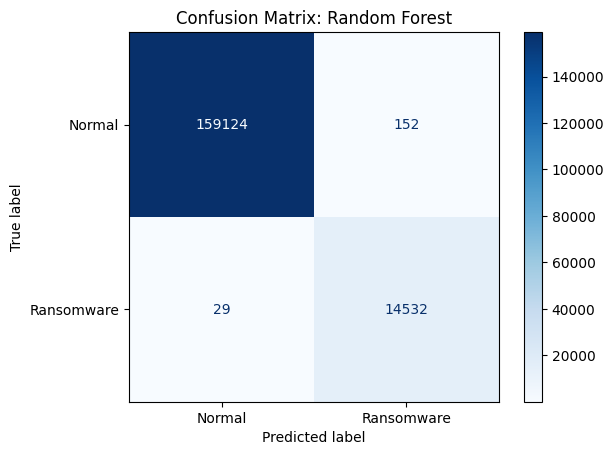


Results for: XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    159276
           1       0.99      1.00      0.99     14561

    accuracy                           1.00    173837
   macro avg       1.00      1.00      1.00    173837
weighted avg       1.00      1.00      1.00    173837

Confusion Matrix for XGBoost:
TN: 159149 | FP: 127
FN: 30 | TP: 14531


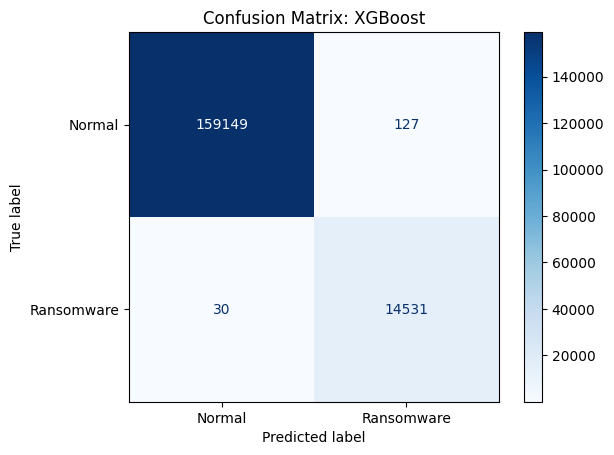


Results for: CatBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    159276
           1       0.98      1.00      0.99     14561

    accuracy                           1.00    173837
   macro avg       0.99      1.00      1.00    173837
weighted avg       1.00      1.00      1.00    173837

Confusion Matrix for CatBoost:
TN: 159047 | FP: 229
FN: 30 | TP: 14531


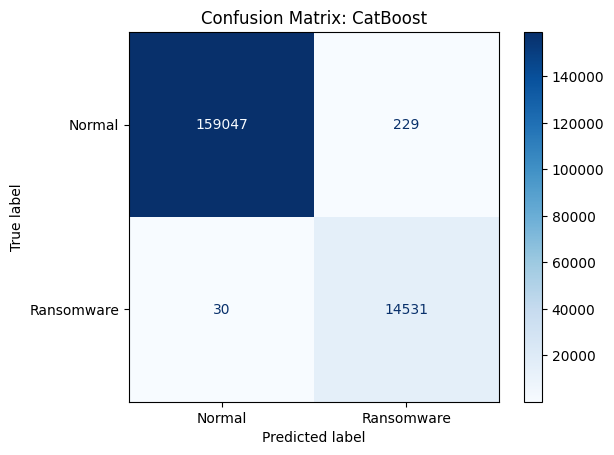


Results for: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.66      0.80    159276
           1       0.21      0.99      0.35     14561

    accuracy                           0.69    173837
   macro avg       0.61      0.83      0.57    173837
weighted avg       0.93      0.69      0.76    173837

Confusion Matrix for Logistic Regression:
TN: 105762 | FP: 53514
FN: 92 | TP: 14469


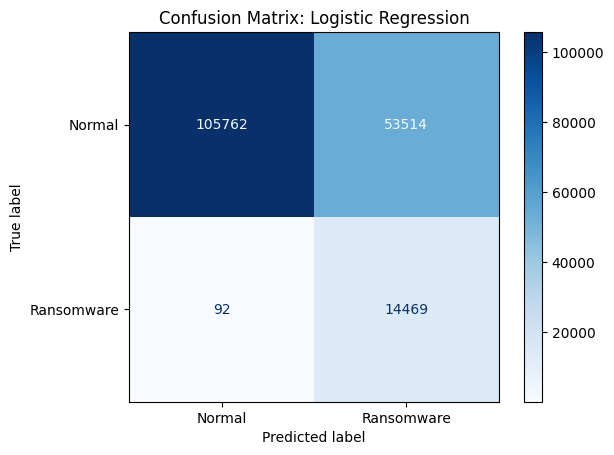


Results for: KNN
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    159276
           1       0.91      1.00      0.95     14561

    accuracy                           0.99    173837
   macro avg       0.96      0.99      0.97    173837
weighted avg       0.99      0.99      0.99    173837

Confusion Matrix for KNN:
TN: 157850 | FP: 1426
FN: 34 | TP: 14527


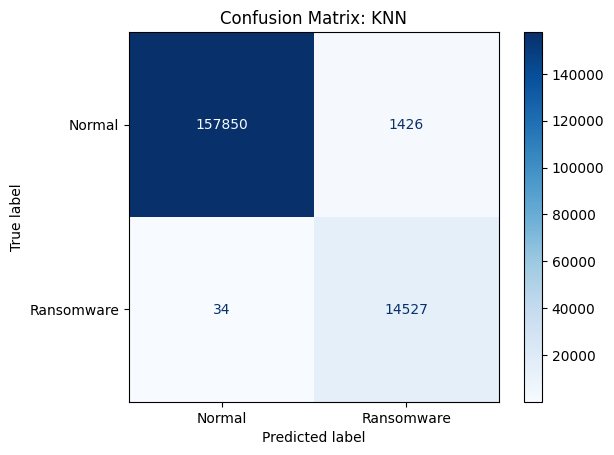

In [8]:

!pip install catboost
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)


X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)


train_df = X_train_encoded.copy()
train_df['label'] = y_train

df_ransom = train_df[train_df['label'] == 1]
df_normal = train_df[train_df['label'] == 0].sample(len(df_ransom), random_state=42)

train_balanced = pd.concat([df_ransom, df_normal])
X_train_final = train_balanced.drop('label', axis=1)
y_train_final = train_balanced['label']


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_encoded)


models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric="logloss"),
    "CatBoost": CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


for name, model in models.items():
    print(f"\n" + "="*30)
    print(f"Results for: {name}")
    print("="*30)


    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train_final)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_final, y_train_final)
        y_pred = model.predict(X_test_encoded)


    print(classification_report(y_test, y_pred))


    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:")
    print(f"TN: {cm[0,0]} | FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]} | TP: {cm[1,1]}")


    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ransomware'])
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()